# Summer '26
## Author: Zane Collins
## Last Updated: 06/17/2026


# Imports

In [1]:
from hapi import *

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import pickle
import seaborn as sns

from scipy.signal import correlate


# imp
os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/')
from bin_spec import bin_spectrum
from exo_spec_simv2 import *
from exo_spec_simv2 import run_cross_correlation
os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks')
%matplotlib widget

In [3]:
os.getcwd()

'/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks'

# Parsing

In [4]:
data_dir = '/Volumes/externalssd/data'

In [5]:
db_begin("HAPI_DB");

Using HAPI_DB

CH4
                     Lines parsed: 9009
CH4_iso2
                     Lines parsed: 11300
H2O_iso3
                     Lines parsed: 763
H2O_iso1
                     Lines parsed: 3425
CH4_iso1
                     Lines parsed: 23241
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 983


In [6]:
tableList()

dict_keys(['sampletab', 'CH4', 'CH4_iso2', 'H2O_iso3', 'H2O_iso1', 'CH4_iso1', 'H2O', 'H2O_iso2'])

In [7]:
wl_min = 3.1
wl_max = 3.5
native_dwn = 0.001     # cm^-1, native HITRAN-resolution sampling (HAPI side)

wn_min = 1e4/wl_max
wn_max = 1e4/wl_min


## CH4 & Water Fetching

In [8]:
# # Isotopes to download:
# ch4_isotopes = [1,2]
# h2o_isotopes = [1,2,3]

In [9]:
# for isotope in ch4_isotopes:
#     fetch(f"CH4_iso{isotope}", 6, isotope, wn_min, wn_max)
# for isotope in h2o_isotopes:
#     fetch(f"H2O_iso{isotope}", 1, isotope, wn_min, wn_max)

# Helper Functions

In [ ]:
def compute_transmission(molecule, isotope, dwn, T = 288, p = 1, column_density = 1e12, path_length = 1e5,scale_factor = 1.0):

    #Check if the molecule and isotope are in the database
    table_name = f"{molecule}_iso{isotope}"
    # if table_name not in [t[0] for t in tableList()]:
    #     raise ValueError(f"{molecule} with isotope {isotope} not found in database. Table {table_name}")
    
    #Fetch the absorption coefficients for the specified molecule and isotope
    wn_grid, coef = absorptionCoefficient_Voigt(
            Components=[(6, isotope, 1)],
            SourceTables=table_name,
            WavenumberRange=(wn_min, wn_max),
            WavenumberStep=dwn,
            Environment={'T': T, 'p': p} 
        )
    
    # Calculate the transmission using the Beer-Lambert law
    tau = coef * column_density * path_length

    tau *= scale_factor

    transmission = np.exp(-tau)

    wavelength_grid = 1e4 / wn_grid
    wavelength_grid
    resolution = np.median(wn_grid) / dwn

    return wavelength_grid, transmission, resolution

def generate_res_isotope_dict(molecules, isotopes_dict, dwns, 
                              T=288, p=1, column_density=1e12, 
                              path_length=1e5, scale_factor=1.0):
    """
    Generate nested dictionary: resolution -> molecule -> isotope -> data
    """
    res_dict = {}   # Main dictionary: res_key -> mol -> iso -> data
    
    for dwn in dwns:
        for mol in molecules:
            isotopes = isotopes_dict.get(mol, [])
            
            for iso in isotopes:
                # Compute the spectrum
                wl, trans, resolution = compute_transmission(
                    mol, iso, dwn, T, p, column_density, path_length, scale_factor
                )
                
                # Use clean integer key for resolution
                res_key = int(round(resolution))
                
                # Initialize nested structure if needed
                if res_key not in res_dict:
                    res_dict[res_key] = {}
                if mol not in res_dict[res_key]:
                    res_dict[res_key][mol] = {}
                
                # Store the data
                res_dict[res_key][mol][iso] = {
                    'wavelength_grid': wl,
                    'transmission': trans,
                    'resolution': resolution,      # keep float if you want
                    'dwn': dwn
                }
                
                print(f"Added: R={res_key} | {mol} iso{iso} | dwn={dwn}")
    
    return res_dict
        
def create_combined_transmission(data_dict, molecule_abundances, res, T=None, p=None, scale_factor=None):
    """
    molecule_abundances: dict[molecule] = dict[isotope] = fractional abundance
    Example: {'CH4': {1: 0.95, 2: 0.05}}
    """
    tau_total = None
    wl_grid = None
    
    print(f"DEBUG: Creating combined spectrum at res={res}")
    print(f"DEBUG: Abundances requested: {molecule_abundances}")
    
    for mol, iso_abunds in molecule_abundances.items():
        for iso, frac in iso_abunds.items():
            try:
                data = data_dict[res][mol][iso]
                current_wl = data['wavelength_grid']
                trans = data['transmission']
                print(f"  ✓ Using {mol} iso{iso} with weight {frac:.4f} | mean trans = {trans.mean():.4f}")
            except KeyError as e:
                print(f"  ✗ Missing data for {mol} iso {iso} at res {res} → {e}")
                continue
                
            if wl_grid is None:
                wl_grid = current_wl.copy()
            
            tau = -np.log(np.clip(trans, 1e-10, 1.0))
            tau_total = tau * frac if tau_total is None else tau_total + tau * frac
    
    if tau_total is None:
        raise ValueError("No data found for any species")
    
    combined_trans = np.exp(-tau_total)
    print(f"DEBUG: Final combined spectrum mean = {combined_trans.mean():.4f}\n")
    
    return wl_grid, combined_trans


# Create binned dictionary
def create_binned_versions(parent_dict, R_values):
    """
    Take the high-res parent and bin it to multiple target resolutions.
    """
    binned_dict = {}   # resolution -> molecule -> isotope -> data
    
    for res_key in parent_dict.keys():           # usually just one fine resolution
        for mol in parent_dict[res_key].keys():
            for iso in parent_dict[res_key][mol].keys():
                data = parent_dict[res_key][mol][iso]
                wl_fine = data['wavelength_grid']
                trans_fine = data['transmission']
                
                for R in R_values:

                    # Ensure ascending wavelength order (critical for SpectRes)
                    sort_idx = np.argsort(wl_fine)
                    wl_fine = wl_fine[sort_idx]
                    trans_fine = trans_fine[sort_idx]

                    
                    wl_binned, trans_binned, _ = bin_spectrum(
                        wl_fine, trans_fine, R
                    )
                    
                    if R not in binned_dict:
                        binned_dict[R] = {}
                    if mol not in binned_dict[R]:
                        binned_dict[R][mol] = {}
                    
                    binned_dict[R][mol][iso] = {
                        'wavelength_grid': wl_binned,
                        'transmission': trans_binned,
                        'resolution': R,
                        'parent_resolution': res_key
                    }
                    
                    print(f"Binned {mol} iso{iso} to R = {R:,}")
    
    return binned_dict


# Noise injection
def inject_poisson_noise(data, SNR):

    signal = np.average(data)  # Representative signal level for scaling noise
    print(f"Average signal level: {signal:.4e}")
    scale = signal / SNR if signal > 0 else 1.0 
    print(f"scale factor: {scale:.4e} for SNR={SNR}")

    poisson_noise = np.random.poisson(lam=data)
    poisson_noise = poisson_noise - data  # Center the noise around zero
    
    noisy_data = data + poisson_noise * scale / np.sqrt(signal)  # Scale noise by SNR and signal level
    noisy_data = np.clip(noisy_data, 0, None)  # Ensure non-negative values

    errorbars = np.sqrt(data) * scale / np.sqrt(signal)  # Poisson noise error bars

    return noisy_data, errorbars

def inject_gaussian_noise(data, SNR, seed = 8):

    depth = 1.0 - data          # or np.abs(1.0 - data) if baseline isn't exactly 1
    signal_level = np.max(depth)   # Peak depth
    # signal_level = np.sqrt(np.mean(depth**2))   # RMS depth
    
    sigma = signal_level / SNR
    # print(f"Signal level: {signal_level:.4e}, Noise std dev: {sigma:.4e} for SNR={SNR}")

    nchan = len(data)
    rng = np.random.default_rng(seed)

    random_pertubations = sigma*rng.standard_normal(nchan)
    # print(f"Actual noise std: {random_pertubations.std():.4e} | Max |noise|: {np.abs(random_pertubations).max():.4e}")

    


    synthetic_atmosphere = data + random_pertubations 
    synthetic_atmosphere = np.clip(synthetic_atmosphere, 0, None) 
    
    errorbars = np.full_like(data, sigma) 
    return synthetic_atmosphere, errorbars

def run_full_isotope_cross_correlation(
    
    parent_dict,
    snr_values,
    resolution_values,
    abundance_scenarios,           # list of dicts: e.g. [{'CH4': {1: 0.95, 2: 0.05}}, ...]
    T=288, p=1.0,
    scale_factor=1.0,
    noise_seed=42
):
    """
    Full pipeline:
      - Bin parent spectra to multiple resolutions
      - create combined spectra for multiple abundance scenarios
      - inject noise into combined spectra
      - Cross-correlate ALL clean templates vs ALL noisy data
      - compute CCF SNR
        - Noise estimated from set nose window
      - append results into dictionary
    """

    results = []
    rng = np.random.default_rng(noise_seed)

    # 1. Create binned versions once
    print("Creating binned versions...")
    data_dict = create_binned_versions(parent_dict, resolution_values)

    # 2. Loop over resolutions
    for res in resolution_values:
        print(f"\n=== Resolution: {res:,} ===")

        # 3. Create clean combined spectra for every abundance scenario
        clean_templates = {}
        for i, abundances in enumerate(abundance_scenarios):
            
            wl_grid, combined_trans = create_combined_transmission(
                data_dict, abundances, res=res, T=T, p=p
            )

            clean_templates[i] = {
                'wavelength_grid': wl_grid.copy(),
                'transmission': combined_trans.copy(),
                'abundances': abundances
                }
        # 4. For each abundance scenario, create noisy versions
        for scenario_idx, abundances in enumerate(abundance_scenarios):
            # Grab scenario data
            clean_data = clean_templates[scenario_idx]
            wl_grid = np.array(clean_data['wavelength_grid'], copy=True)
            combined_trans = np.array(clean_data['transmission'], copy=True)

            for snr in snr_values:
                noisy_trans, _ = inject_gaussian_noise(combined_trans, snr)

                # 5. Cross-correlate this noisy spectrum against ALL clean templates
                for template_idx, template in clean_templates.items():
                    template_spectra = np.array(template['transmission'], copy = True)

                    # Normalize
                    parent_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
                    test_norm   = (noisy_trans   - np.mean(noisy_trans))   / np.std(noisy_trans)

                    # Cross-correlation
                    ccf = correlate(parent_norm, test_norm, mode='full')
                    ccf /= np.sqrt(np.sum(parent_norm**2) * np.sum(test_norm**2))

                    lags = np.arange(-len(parent_norm) + 1, len(parent_norm))

                    # === Improved Noise Estimation: ±3σ from peak (Gaussian assumption) ===
                    max_corr = np.max(ccf)
                    peak_idx = np.argmax(ccf)
                    
                    # Find approximate FWHM (Full Width at Half Maximum)
                    half_max = max_corr / 2.0
                    # Find left and right points where CCF crosses half maximum
                    left_idx = np.where(ccf[:peak_idx] <= half_max)[0]
                    right_idx = np.where(ccf[peak_idx:] <= half_max)[0] + peak_idx
                    
                    left_idx = left_idx[-1] if len(left_idx) > 0 else 0
                    right_idx = right_idx[0] if len(right_idx) > 0 else len(ccf)-1
                    
                    fwhm = right_idx - left_idx
                    sigma = fwhm / 2.355   # Gaussian conversion: FWHM ≈ 2.355 * σ
                    
                    # Exclude ±3σ around the peak
                    exclude_half_width = int(3 * sigma) + 1
                    
                    ccf_length = len(ccf)
                    noise_mask = np.ones(ccf_length, dtype=bool)
                    start = max(0, peak_idx - exclude_half_width)
                    end = min(ccf_length, peak_idx + exclude_half_width)
                    noise_mask[start:end] = False
                    
                    noise_values = ccf[noise_mask]
                    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
                    
                    # Per-lag SNR (what you want)
                    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)

                    results.append({
                        'resolution': res,
                        'snr': snr,
                        'data_abundances': abundances.copy(),
                        'template_abundances': template['abundances'].copy(),
                        'max_correlation': max_corr,
                        'cc_snr': cc_snr.copy(),
                        'noise_std': noise_std,
                        'lags': lags,
                        'ccf': ccf.copy(),
                        'template_index': template_idx,
                        'data_scenario': scenario_idx,

                        # === Spectra ===
                        'wavelength_grid': wl_grid.copy(),
                        'clean_transmission': combined_trans.copy(),
                        'noisy_transmission': noisy_trans.copy(),
                    })

    df = pd.DataFrame(results)
    print(f"\nFinished! Total cross-correlations computed: {len(df)}")
    return df

# Plots

def plot_ccf_comparison(df, resolution, snr, data_abundances, 
                        template_a, template_b, 
                        title=None, figsize=(12, 6), 
                        show_error_bars=False, ccf_snr = False):
    """
    Plot CCF for two templates on the SAME figure with noise window marked.
    """
    # Filter data
    mask = (
        (df['resolution'] == resolution) & 
        (df['snr'] == snr) &
        (df['data_abundances'] == data_abundances)
    )
    subset = df[mask]
    
    if len(subset) == 0:
        print("No matching data found!")
        return

    fig, ax = plt.subplots(figsize=figsize)

    for template_abund, label, color in [
        (template_a, 'Pure ¹²CH₄ Template', 'tab:blue'),
        (template_b, 'Mixed Template', 'tab:orange')
    ]:
        row = subset[subset['template_abundances'] == template_abund]
        if len(row) == 0:
            continue
        row = row.iloc[0]

        lags = np.array(row['lags'])
        ccf = np.array(row['ccf'])
        cc_snr_array = np.array(row['cc_snr'])   # per-lag SNR
        
        # if CC SNR plot, plot cc_snr:
        if ccf_snr:

            # Optional error bars (using 1/sqrt(N) style uncertainty or just noise_std)
            if show_error_bars:
                noise_std = row['noise_std']
                ax.errorbar(lags, cc_snr_array, yerr=noise_std, marker='.', 
                            color=color, ls = 'none', alpha=0.7, capsize=2, label = label)
                ax.set_ylabel('Cross-Correlation SNR')
            else:
                # Plot CCF
                ax.plot(lags, cc_snr_array, color=color, lw=1.4, label=label, alpha = 0.7)
                ax.set_ylabel('Cross-Correlation SNR')

        else:
            # Optional error bars (using 1/sqrt(N) style uncertainty or just noise_std)
            if show_error_bars:
                noise_std = row['noise_std']
                ax.errorbar(lags, ccf, yerr=noise_std, marker='.', 
                            color=color, ls = 'none', alpha=0.7, capsize=2, label = label)
                ax.set_ylabel('Cross-Correlation')

            else:
                # Plot CCF
                ax.plot(lags, ccf, color=color, lw=1.4, label=label, alpha = 0.7)
                ax.set_ylabel('Cross-Correlation')



        # === Mark noise window (±3σ) ===
        peak_idx = np.argmax(ccf)
        # Use the same logic as in your cross-correlation function
        half_max = np.max(ccf) / 2
        left_idx = np.where(ccf[:peak_idx] <= half_max)[0]
        right_idx = np.where(ccf[peak_idx:] <= half_max)[0] + peak_idx
        
        left_idx = left_idx[-1] if len(left_idx) > 0 else 0
        right_idx = right_idx[0] if len(right_idx) > 0 else len(ccf)-1
        
        fwhm = right_idx - left_idx
        sigma = fwhm / 2.355
        exclude_half = int(3 * sigma)

        window_left = lags[max(0, peak_idx - exclude_half)]
        window_right = lags[min(len(lags)-1, peak_idx + exclude_half)]

        ax.axvline(window_left, color=color, ls='--', alpha=0.6, lw=1)
        ax.axvline(window_right, color=color, ls='--', alpha=0.6, lw=1)

    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Lag (pixels)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    if title is None:
        title = f"CCF Comparison @ R={resolution:,}, SNR={snr}"
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

def plot_spectra_grid(df, cases):
    """
    Plot multiple spectra from df_results in a grid.
    
    cases = list of dicts with filters, e.g.:
        cases = [
            {'resolution': 1000,  'snr': 10,  'data_abundances': {'CH4': {1:0.5, 2:0.5}}},
            {'resolution': 5000,  'snr': 50,  'data_abundances': {'CH4': {1:0.5, 2:0.5}}},
            {'resolution': 10000, 'snr': 100, 'data_abundances': {'CH4': {1:0.5, 2:0.5}}},
        ]
    """
    # n_rows = int(np.ceil(len(cases) / n_cols))
    # fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    # axes = axes.flatten()
    plt.figure(figsize=(10,6))

    for i, case in enumerate(cases):
        
        res = case.get('resolution')
        snr = case.get('snr')
        abun = case.get('data_abundances')
        
        # Filter
        if snr != 0:
            mask = (df['resolution'] == res) & (df['snr'] == snr)
        elif snr == 0:
            mask = (df['resolution'] == res)
        if abun is not None:
            mask = mask & (df['data_abundances'] == abun)
        
        subset = df[mask]
        if len(subset) == 0:
            plt.title("No data")
            continue
            
        row = subset.iloc[0]
        
        wl = row['wavelength_grid']
        clean = row['clean_transmission']
        noisy = row['noisy_transmission']
        
        if snr == 0:
            plt.plot(wl, clean, label=f'Clean, R = {res:,}, abund = {abun}', lw=1.0)
        else:
            plt.plot(wl, noisy, label=f'Noisy SNR={snr}, R = {res:,}, abund = {abun}', lw=0.7, alpha=0.85)
        
        # plt.title(f"Spectra for abundances: {abun}")
        plt.xlabel('Wavelength (μm)')
        plt.ylabel('Transmission')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)

    # Hide empty subplots
    # for j in range(i + 1, len(axes)):
    #     axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Cross Correlation Tests

## Generating Data

#### Create hi-res parent spectra

##### FIXME: save as different file type (npz, HDF5, parquet for better storage)

In [28]:
parent_dwn = 0.0005
molecules = ['CH4', 'H2O']
isotopes_dict = {'CH4': [1, 2], 'H2O': [1]}


In [29]:
# 1. Compute the high-resolution parent spectrum once

parent_dict = generate_res_isotope_dict(
    molecules=molecules,
    isotopes_dict=isotopes_dict,
    dwns=[parent_dwn],           # only one fine grid
    scale_factor=5.0
)
# parent_dict now has one key (e.g. 555000) with the fine data

# Save the data

save_path = os.path.join(data_dir, f"parent_spectra_dwn({parent_dwn})_mol({molecules}_{wl_min}_to_{wl_max}).pkl")

with open(save_path, 'wb') as f:
    pickle.dump(parent_dict, f)

print(f"✅ Saved parent_dict to: {save_path}")


{'air': 1.0}
20.773148 seconds elapsed for abscoef; nlines = 23241
Added: R=6082949 | CH4 iso1 | dwn=0.0005
{'air': 1.0}
10.193502 seconds elapsed for abscoef; nlines = 11300
Added: R=6082949 | CH4 iso2 | dwn=0.0005
{'air': 1.0}
0.131843 seconds elapsed for abscoef; nlines = 3425
Added: R=6082949 | H2O iso1 | dwn=0.0005
✅ Saved parent_dict to: /Volumes/externalssd/data/parent_spectra_dwn(0.0005)_mol(['CH4', 'H2O']_3.1_to_3.5).pkl


In [30]:
load_path = os.path.join(data_dir, f"parent_spectra_dwn({parent_dwn})_mol({molecules}_{wl_min}_to_{wl_max}).pkl")

with open(load_path, 'rb') as f:
    parent_dict = pickle.load(f)

print(f"✅ Loaded parent_dict with resolutions: {list(parent_dict.keys())}")

✅ Loaded parent_dict with resolutions: [6082949]


## Cross-Correlating

In [54]:
# Define the abundance scenarios you want to test
abundance_scenarios = [
    {'CH4': {1: 1.0, 2: 0.0}},           # Pure 12CH4
    {'CH4': {1: 0.95, 2: 0.05}},         # Earth-like 13CH4
    {'CH4': {1: 0.99, 2: 0.01}},      # trace 13ch4
    {'CH4': {1: 0.5, 2: 0.5}},           # Equal mixture
    {'CH4': {1:0.9, 2: 0.1}},
    {'H2O': {1:1}},
    {'H2O': {1:0.8}, 'CH4': {1:0.2}},
    {'H2O': {1:0.5}, 'CH4': {1:0.5}}
]

df_results = run_full_isotope_cross_correlation(
    parent_dict=parent_dict,
    snr_values=[1, 5, 10, 25, 50, 100, 500],
    resolution_values=[50,100, 1000, 10000, 100000, 5e5],
    abundance_scenarios=abundance_scenarios,
    molecule='CH4'
)

Creating binned versions...
Binned CH4 iso1 to R = 50
Binned CH4 iso1 to R = 100
Binned CH4 iso1 to R = 1,000
Binned CH4 iso1 to R = 10,000
Binned CH4 iso1 to R = 100,000
Binned CH4 iso1 to R = 500,000.0
Binned CH4 iso2 to R = 50
Binned CH4 iso2 to R = 100
Binned CH4 iso2 to R = 1,000
Binned CH4 iso2 to R = 10,000
Binned CH4 iso2 to R = 100,000
Binned CH4 iso2 to R = 500,000.0
Binned H2O iso1 to R = 50
Binned H2O iso1 to R = 100
Binned H2O iso1 to R = 1,000
Binned H2O iso1 to R = 10,000
Binned H2O iso1 to R = 100,000
Binned H2O iso1 to R = 500,000.0

=== Resolution: 50 ===
DEBUG: Creating combined spectrum at res=50
DEBUG: Abundances requested: {'CH4': {1: 1.0, 2: 0.0}}
  ✓ Using CH4 iso1 with weight 1.0000 | mean trans = 0.9840
  ✓ Using CH4 iso2 with weight 0.0000 | mean trans = 0.9845
DEBUG: Final combined spectrum mean = 0.9840

DEBUG: Creating combined spectrum at res=50
DEBUG: Abundances requested: {'CH4': {1: 0.95, 2: 0.05}}
  ✓ Using CH4 iso1 with weight 0.9500 | mean trans = 0

/var/folders/0y/zn1dltkd6hj_8m8pq81r_98r0000gn/T/ipykernel_94480/2372699991.py:252: RuntimeWarning: invalid value encountered in divide
  parent_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
/var/folders/0y/zn1dltkd6hj_8m8pq81r_98r0000gn/T/ipykernel_94480/2372699991.py:253: RuntimeWarning: invalid value encountered in divide
  test_norm   = (noisy_trans   - np.mean(noisy_trans))   / np.std(noisy_trans)



=== Resolution: 10,000 ===
DEBUG: Creating combined spectrum at res=10000
DEBUG: Abundances requested: {'CH4': {1: 1.0, 2: 0.0}}
  ✓ Using CH4 iso1 with weight 1.0000 | mean trans = 0.9870
  ✓ Using CH4 iso2 with weight 0.0000 | mean trans = 0.9873
DEBUG: Final combined spectrum mean = 0.9870

DEBUG: Creating combined spectrum at res=10000
DEBUG: Abundances requested: {'CH4': {1: 0.95, 2: 0.05}}
  ✓ Using CH4 iso1 with weight 0.9500 | mean trans = 0.9870
  ✓ Using CH4 iso2 with weight 0.0500 | mean trans = 0.9873
DEBUG: Final combined spectrum mean = 0.9869

DEBUG: Creating combined spectrum at res=10000
DEBUG: Abundances requested: {'CH4': {1: 0.99, 2: 0.01}}
  ✓ Using CH4 iso1 with weight 0.9900 | mean trans = 0.9870
  ✓ Using CH4 iso2 with weight 0.0100 | mean trans = 0.9873
DEBUG: Final combined spectrum mean = 0.9870

DEBUG: Creating combined spectrum at res=10000
DEBUG: Abundances requested: {'CH4': {1: 0.5, 2: 0.5}}
  ✓ Using CH4 iso1 with weight 0.5000 | mean trans = 0.9870
  

/Users/zaniaccollins/miniconda3/envs/sgl-science/lib/python3.11/site-packages/scipy/signal/_signaltools.py:283: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return convolve(in1, _reverse_and_conj(in2, xp), mode, method)



=== Resolution: 500,000.0 ===
DEBUG: Creating combined spectrum at res=500000.0
DEBUG: Abundances requested: {'CH4': {1: 1.0, 2: 0.0}}
  ✓ Using CH4 iso1 with weight 1.0000 | mean trans = 0.9870
  ✓ Using CH4 iso2 with weight 0.0000 | mean trans = 0.9873
DEBUG: Final combined spectrum mean = 0.9870

DEBUG: Creating combined spectrum at res=500000.0
DEBUG: Abundances requested: {'CH4': {1: 0.95, 2: 0.05}}
  ✓ Using CH4 iso1 with weight 0.9500 | mean trans = 0.9870
  ✓ Using CH4 iso2 with weight 0.0500 | mean trans = 0.9873
DEBUG: Final combined spectrum mean = 0.9869

DEBUG: Creating combined spectrum at res=500000.0
DEBUG: Abundances requested: {'CH4': {1: 0.99, 2: 0.01}}
  ✓ Using CH4 iso1 with weight 0.9900 | mean trans = 0.9870
  ✓ Using CH4 iso2 with weight 0.0100 | mean trans = 0.9873
DEBUG: Final combined spectrum mean = 0.9870

DEBUG: Creating combined spectrum at res=500000.0
DEBUG: Abundances requested: {'CH4': {1: 0.5, 2: 0.5}}
  ✓ Using CH4 iso1 with weight 0.5000 | mean tr

## Plotting Spectra

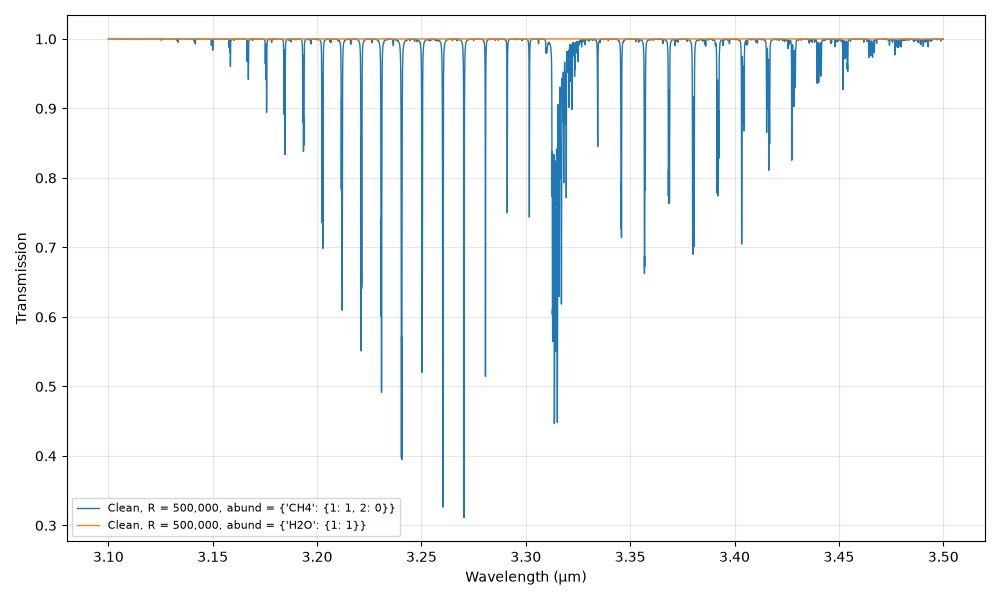

In [59]:
cases = [
    {'resolution': 500000,  'snr': 0,  'data_abundances': {'CH4': {1: 1, 2: 0}}},
    {'resolution': 500000, 'snr': 0, 'data_abundances': {'H2O': {1: 1}}},
    # {'resolution': 500000, 'snr': 0, 'data_abundances': {'CH4': {1: 0.95,2:0.05}}},
]

plot_spectra_grid(df_results, cases)

## Plotting Results

In [57]:
for i in abundance_scenarios:
    print(i)

{'CH4': {1: 1.0, 2: 0.0}}
{'CH4': {1: 0.95, 2: 0.05}}
{'CH4': {1: 0.99, 2: 0.01}}
{'CH4': {1: 0.5, 2: 0.5}}
{'CH4': {1: 0.9, 2: 0.1}}
{'H2O': {1: 1}}
{'H2O': {1: 0.8}, 'CH4': {1: 0.2}}
{'H2O': {1: 0.5}, 'CH4': {1: 0.5}}


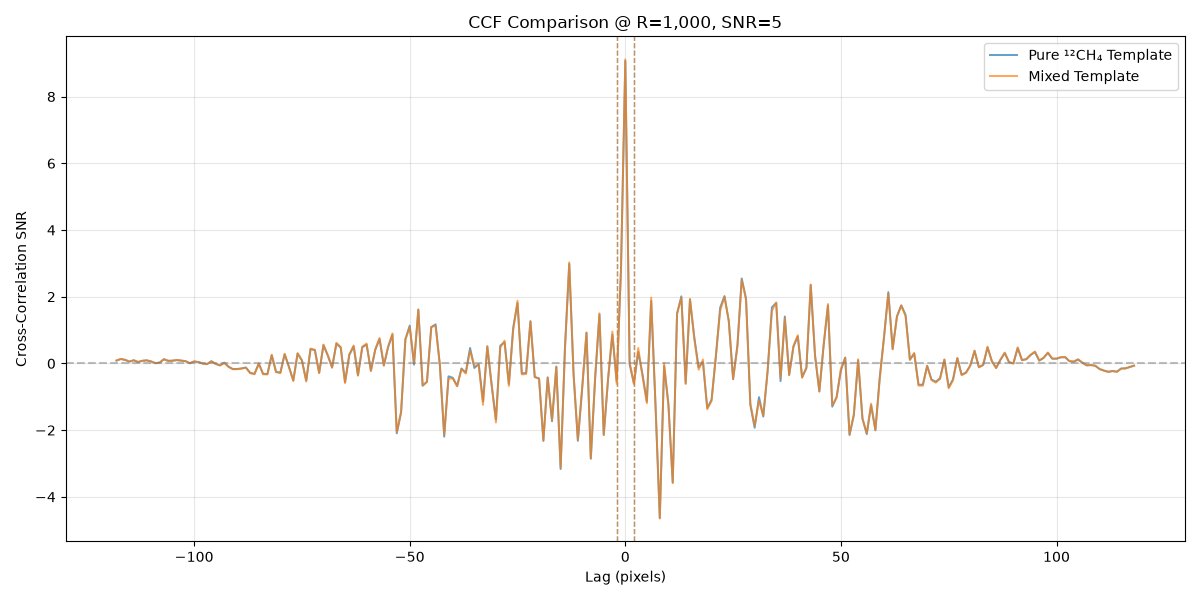

In [58]:
resolution_to_plot = 1000
snr_to_plot = 5

# Define the abundance dictionaries exactly as stored in your DataFrame
data_abundances = {'H2O': {1: 0.8}, 'CH4': {1: 0.2}}
template_a ={'H2O': {1: 0.5}, 'CH4': {1: 0.5}}
template_b ={'CH4': {1: 1.0, 2: 0.0}}


plot_ccf_comparison(
    df=df_results,
    resolution=resolution_to_plot,
    snr=snr_to_plot,
    data_abundances=data_abundances,
    template_a=template_a,
    template_b=template_b, show_error_bars=False, ccf_snr=True
)

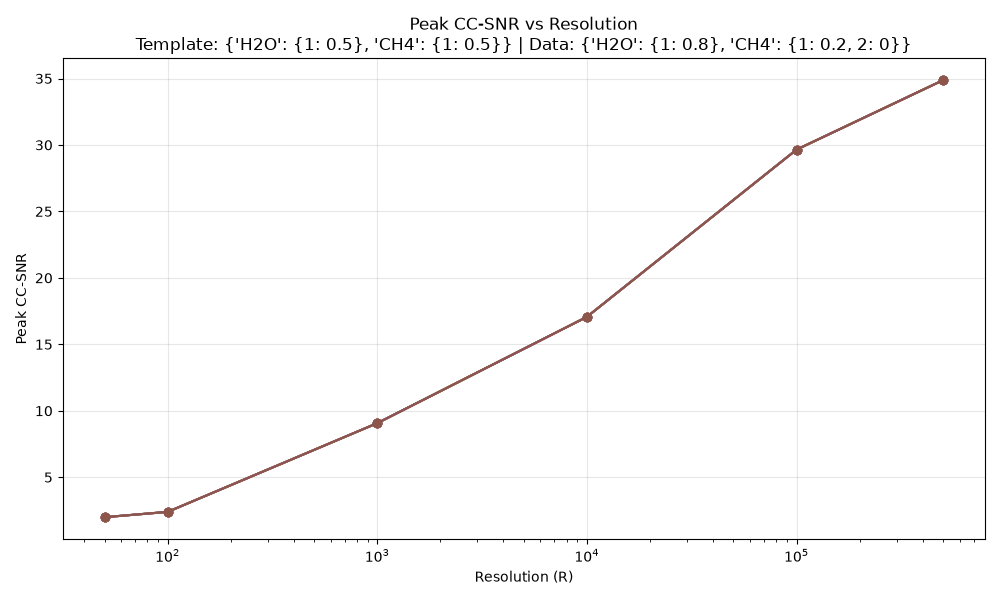

In [49]:
template_abundances_for_plot = {'H2O': {1:0.5}, 'CH4': {1:0.5}}
data_abundances_for_plot = {'H2O': {1:0.8}, 'CH4': {1:0.2, 2:0}}
snr_to_plot = 5

mask = (
    (df_results['template_abundances'] == template_abundances_for_plot) & 
    (df_results['data_abundances'] == data_abundances_for_plot) & 
    (df_results['snr'] == snr_to_plot)
)
subset = df_results[mask].copy()
subset['peak_cc_snr'] = subset['cc_snr'].apply(np.max)

grouped = subset.groupby('resolution')['peak_cc_snr'].mean().reset_index()

plt.figure(figsize=(10,6))

for res in subset['resolution']:
    plt.plot(grouped['resolution'], grouped['peak_cc_snr'], marker='o', linestyle='-')


plt.xlabel('Resolution (R)')
plt.ylabel('Peak CC-SNR')
plt.title(f'Peak CC-SNR vs Resolution\nTemplate: {template_abundances_for_plot} | Data: {data_abundances_for_plot}')
plt.grid(True, alpha=0.3)
plt.xscale('log')   # Usually helpful for resolution
plt.tight_layout()
plt.show()


### Heatmap

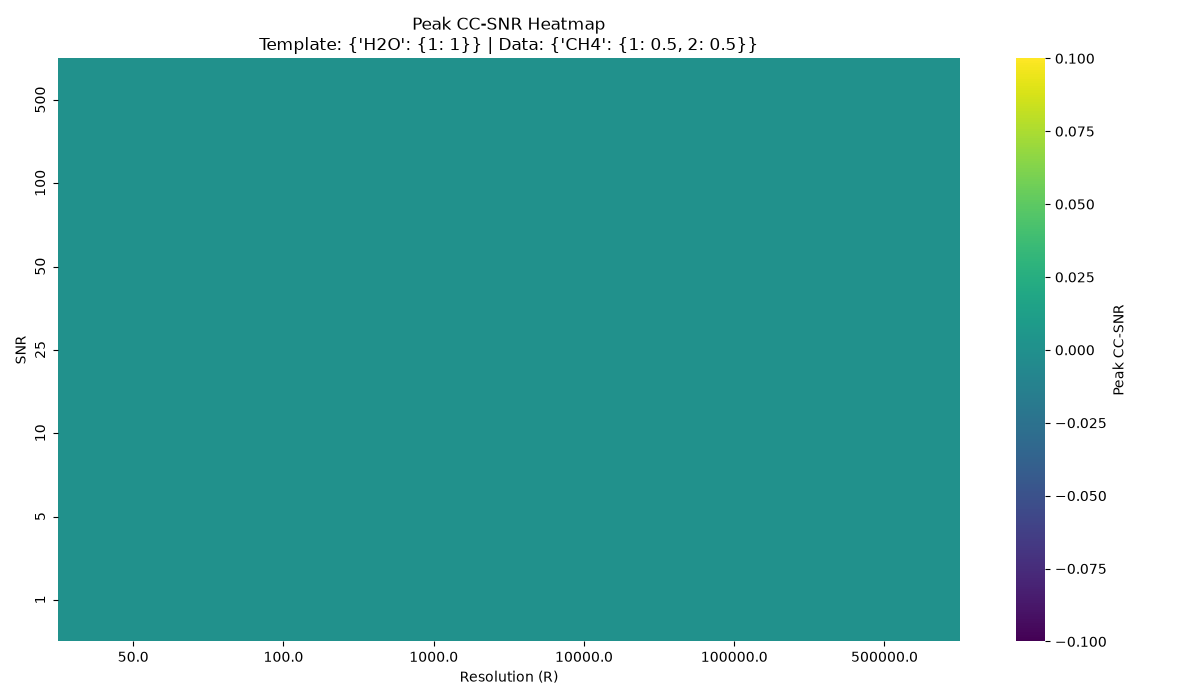

In [40]:
# template_abundances_for_plot = {'CH4': {1: .99, 2: .01}}
template_abundances_for_plot = {'H2O': {1:1}}
data_abundances_for_plot = {'CH4': {1: 0.5, 2: 0.5}}

# Filter
mask = (
    (df_results['template_abundances'] == template_abundances_for_plot) & 
    (df_results['data_abundances'] == data_abundances_for_plot)
)
subset = df_results[mask].copy()

# Compute peak CC-SNR per row (since cc_snr is an array)
subset['peak_cc_snr'] = subset['cc_snr'].apply(np.max)

# Create pivot table for heatmap
pivot = subset.pivot_table(
    index='snr', 
    columns='resolution', 
    values='peak_cc_snr', 
    aggfunc='max'          # or 'max' if you prefer
)

# Sort axes nicely
pivot = pivot.sort_index(axis=0).sort_index(axis=1)
pivot = pivot.sort_index(ascending=False)
# ======================
# Plot Heatmap
# ======================
plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot, 
    cmap='viridis',           # or 'plasma', 'inferno', 'coolwarm'
    # annot=True,               # show numbers in cells
    fmt=".2f", 
    # linewidths=0.5,
    cbar_kws={'label': 'Peak CC-SNR'}
)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR')
plt.title(f'Peak CC-SNR Heatmap\nTemplate: {template_abundances_for_plot} | Data: {data_abundances_for_plot}')

plt.tight_layout()
plt.show()

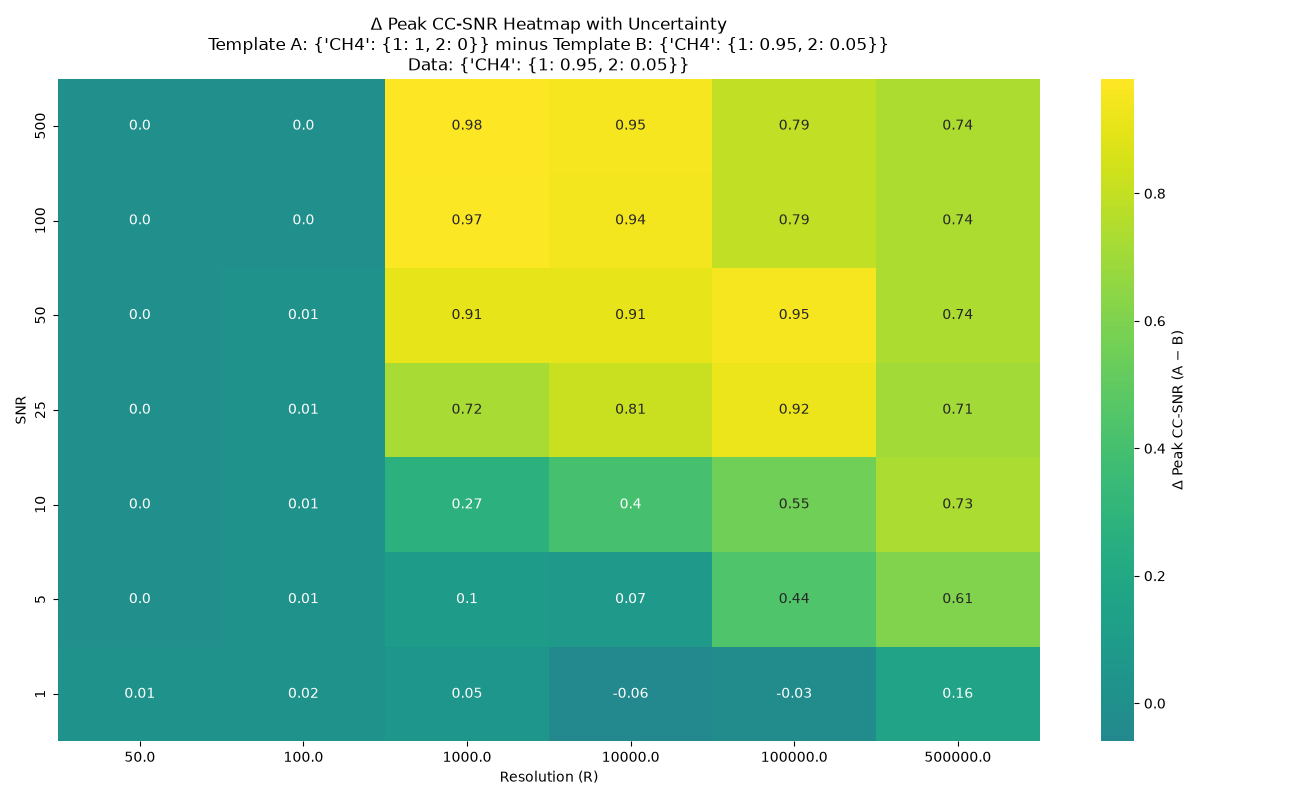

In [61]:
template_A = {'CH4': {1: 1, 2: 0}}
template_B = {'CH4': {1: 0.95, 2: 0.05}}
data_abundances = {'CH4': {1: 0.95, 2: 0.05}}

def get_peak_values(df, template_abundances, data_abundances, metric='cc_snr'):
    mask = (
        (df['template_abundances'] == template_abundances) & 
        (df['data_abundances'] == data_abundances)
    )
    subset = df[mask].copy()
    
    if metric == 'cc_snr':
        subset['peak_value'] = subset['cc_snr'].apply(np.max)
        subset['error'] = 0.0
        value_name = 'Peak CC-SNR'
    else:
        subset['peak_value'] = subset['max_correlation']
        subset['error'] = subset['noise_std']
        value_name = 'Max Correlation'
    
    return subset[['resolution', 'snr', 'peak_value', 'error']], value_name


# ======================
metric_to_use = 'cc_snr'

df_A, value_name = get_peak_values(df_results, template_A, data_abundances, metric=metric_to_use)
df_B, _ = get_peak_values(df_results, template_B, data_abundances, metric=metric_to_use)

merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

merged['delta'] = merged['peak_value_A'] - merged['peak_value_B']
merged['delta_error'] = np.sqrt(merged['error_A']**2 + merged['error_B']**2)
merged['delta'] = merged['delta'].round(2)

# ======================
# Pivot for heatmap
# ======================
pivot = merged.pivot_table(
    index='snr', 
    columns='resolution', 
    values='delta',
    aggfunc='mean'
)
pivot = pivot.sort_index(ascending=False)

# ======================
# Create annotation with ± error
# ======================
annot = pivot.copy().astype(str)

for i, snr in enumerate(pivot.index):
    for j, res in enumerate(pivot.columns):
        delta = pivot.iloc[i, j]
        delta_err = merged[(merged['snr'] == snr) & (merged['resolution'] == res)]['delta_error'].mean()
        annot.iloc[i, j] = f"{delta:.2f}\n±{delta_err:.2f}"

# ======================
# Plot
# ======================
plt.figure(figsize=(13, 8))

sns.heatmap(
    pivot,
    cmap='viridis',
    center=0,
    annot=True,
    fmt='', 
    cbar_kws={'label': f'Δ {value_name} (A − B)'}
)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR')
plt.title(
    f'Δ {value_name} Heatmap with Uncertainty\n'
    f'Template A: {template_A} minus Template B: {template_B}\n'
    f'Data: {data_abundances}'
)

plt.tight_layout()
plt.show()

## Debug

In [ ]:
data_dict = create_binned_versions(parent_dict, [50,100, 1000, 10000, 100000, 5e5])


Binned CH4 iso1 to R = 50
Binned CH4 iso1 to R = 100
Binned CH4 iso1 to R = 1,000
Binned CH4 iso1 to R = 10,000
Binned CH4 iso1 to R = 100,000
Binned CH4 iso1 to R = 500,000.0
Binned CH4 iso2 to R = 50
Binned CH4 iso2 to R = 100
Binned CH4 iso2 to R = 1,000
Binned CH4 iso2 to R = 10,000
Binned CH4 iso2 to R = 100,000
Binned CH4 iso2 to R = 500,000.0


Checking stored spectra...
Pure mean trans: 0.9870092183731994
Mixed mean trans: 0.9867086391310979


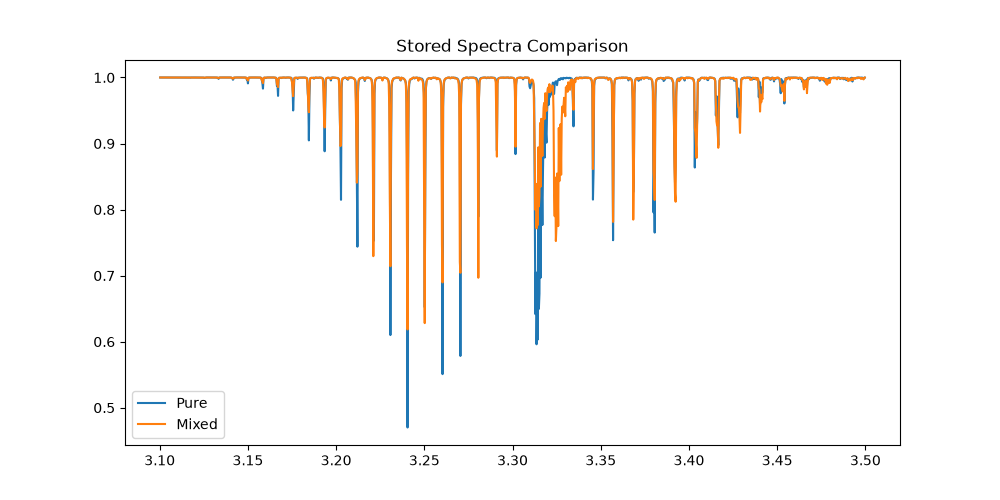

In [ ]:
# Check if different scenarios have different spectra
print("Checking stored spectra...")

row1 = df_results[(df_results['data_abundances'] == {'CH4': {1:1.0,2:0}}) & 
                  (df_results['resolution'] == 10000)].iloc[0]

row2 = df_results[(df_results['data_abundances'] == {'CH4': {1:0.5,2:0.5}}) & 
                  (df_results['resolution'] == 10000)].iloc[0]

print("Pure mean trans:", row1['clean_transmission'].mean())
print("Mixed mean trans:", row2['clean_transmission'].mean())

# Plot to confirm they are different
plt.figure(figsize=(10,5))
plt.plot(row1['wavelength_grid'], row1['clean_transmission'], label='Pure')
plt.plot(row2['wavelength_grid'], row2['clean_transmission'], label='Mixed')
plt.legend()
plt.title('Stored Spectra Comparison')
plt.show()

In [ ]:
# Delete old result if it exists
if 'df_results' in globals():
    del df_results

# Re-run with the fixed function
df_results = run_full_isotope_cross_correlation(
    parent_dict=parent_dict,
    snr_values=[5, 10, 50, 100],
    resolution_values=[1000, 5000, 10000, 50000, 100000],
    abundance_scenarios=[
        {'CH4': {1: 1.0, 2: 0.0}},
        {'CH4': {1: 0.95, 2: 0.05}},
        {'CH4': {1: 0.5, 2: 0.5}},
    ]
)

Creating binned versions...
Binned CH4 iso1 to R = 1,000
Binned CH4 iso1 to R = 5,000
Binned CH4 iso1 to R = 10,000
Binned CH4 iso1 to R = 50,000
Binned CH4 iso1 to R = 100,000
Binned CH4 iso2 to R = 1,000
Binned CH4 iso2 to R = 5,000
Binned CH4 iso2 to R = 10,000
Binned CH4 iso2 to R = 50,000
Binned CH4 iso2 to R = 100,000

=== Resolution: 1,000 ===
DEBUG: Creating combined spectrum at res=1000
DEBUG: Abundances requested: {'CH4': {1: 1.0, 2: 0.0}}
  ✓ Using CH4 iso1 with weight 1.0000 | mean trans = 0.9869
  ✓ Using CH4 iso2 with weight 0.0000 | mean trans = 0.9872
DEBUG: Final combined spectrum mean = 0.9869

DEBUG: Creating combined spectrum at res=1000
DEBUG: Abundances requested: {'CH4': {1: 0.95, 2: 0.05}}
  ✓ Using CH4 iso1 with weight 0.9500 | mean trans = 0.9869
  ✓ Using CH4 iso2 with weight 0.0500 | mean trans = 0.9872
DEBUG: Final combined spectrum mean = 0.9869

DEBUG: Creating combined spectrum at res=1000
DEBUG: Abundances requested: {'CH4': {1: 0.5, 2: 0.5}}
  ✓ Using 

Diagnostic for R= 10000 SNR= 50
Peak CC-SNR Pure  : 18.76498314509846
Peak CC-SNR Trace : 18.65643045859617


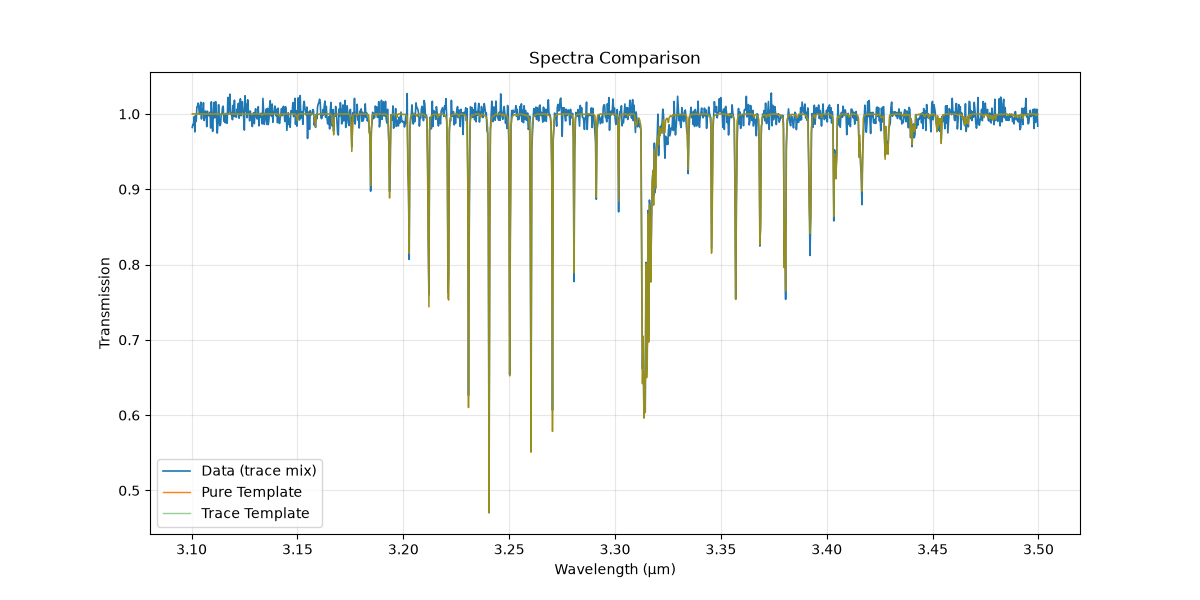

In [ ]:
# Pick a problematic cell (high positive delta)
res = 10000
snr = 50

print("Diagnostic for R=", res, "SNR=", snr)

# Get the three spectra
mask_data = (df_results['data_abundances'] == {'CH4': {1: 0.95, 2: 0.05}})
mask_pure = (df_results['template_abundances'] == {'CH4': {1: 1, 2: 0}})
mask_trace = (df_results['template_abundances'] == {'CH4': {1: 0.95, 2: 0.05}})

row_data = df_results[mask_data & (df_results['resolution'] == res) & (df_results['snr'] == snr)].iloc[0].copy()
row_pure = df_results[mask_pure & (df_results['resolution'] == res)].iloc[0].copy()
row_trace = df_results[mask_trace & (df_results['resolution'] == res)].iloc[0].copy()

print("Peak CC-SNR Pure  :", row_pure['cc_snr'].max())
print("Peak CC-SNR Trace :", row_trace['cc_snr'].max())

# Plot the three spectra
plt.figure(figsize=(12, 6))
plt.plot(row_data['wavelength_grid'], row_data['noisy_transmission'], label='Data (trace mix)', lw=1.2)
plt.plot(row_pure['wavelength_grid'], row_pure['clean_transmission'], label='Pure Template', lw=1.0)
plt.plot(row_trace['wavelength_grid'], row_trace['clean_transmission'], label='Trace Template', lw=1.0, alpha = 0.5)
plt.xlabel('Wavelength (μm)')
plt.ylabel('Transmission')
plt.title('Spectra Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()